# Submission Summary

| Field | Value |
|---|---|
| Group number | 28 |
| Your full name | *(your name here)* |
| Dataset | Stroke Prediction |
| Depth track | Classification Depth |
| Team members | *(full names of all members)* |
| Final model | Random Forest, class_weight='balanced', threshold=0.35 |
| Stratified dummy F1 / ROC AUC | *(fill after run)* |
| Final model F1 / ROC AUC | *(fill after run)* |
| Leakage columns dropped | None found |
| Full run time on Colab | *(fill after run)* |

# Part 1. Data Foundation

In [9]:
# Install required libraries
!pip install kagglehub imbalanced-learn -q

In [10]:
import kagglehub
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Load Dataset from Kaggle
We use `kagglehub` to download the Stroke Prediction dataset directly inside the notebook. This ensures the notebook is fully reproducible on a fresh Colab session without any manual file uploads or API tokens.

In [11]:
# Download dataset using kagglehub
path = kagglehub.dataset_download('fedesoriano/stroke-prediction-dataset')
print('Dataset downloaded to:', path)

# Find the CSV file
for f in os.listdir(path):
    print(f)

csv_path = os.path.join(path, 'healthcare-dataset-stroke-data.csv')
df = pd.read_csv(csv_path)
print(f'\nDataset shape: {df.shape}')
df.head()

Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1
healthcare-dataset-stroke-data.csv

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 1.2 Push to SQLite and Run SQL Queries
Loading into SQLite lets us use familiar SQL queries to explore the data before moving into pandas. Each query is followed by an interpretation.

In [12]:
# Push to SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('stroke', conn, index=False, if_exists='replace')
print('Data loaded into SQLite.')

Data loaded into SQLite.


In [13]:
# SQL Query 1: Stroke rate by hypertension and heart disease status
q1 = """
SELECT hypertension, heart_disease,
       COUNT(*) AS total,
       SUM(stroke) AS stroke_cases,
       ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct
FROM stroke
GROUP BY hypertension, heart_disease
ORDER BY stroke_rate_pct DESC
"""
pd.read_sql(q1, conn)

,hypertension,heart_disease,total,stroke_cases,stroke_rate_pct
0,1,1,64,13,20.31
1,0,1,212,34,16.04
2,1,0,434,53,12.21
3,0,0,4400,149,3.39


**What we learned:** Patients with both hypertension AND heart disease have a dramatically higher stroke rate than those with neither condition. This tells us these two comorbidities are likely strong predictors, and their interaction may be worth engineering as a feature.

In [14]:
# SQL Query 2: Stroke rate by age band
q2 = """
SELECT
    CASE
        WHEN age < 30 THEN 'Under 30'
        WHEN age < 50 THEN '30-49'
        WHEN age < 65 THEN '50-64'
        ELSE '65+'
    END AS age_band,
    COUNT(*) AS total,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct
FROM stroke
GROUP BY age_band
ORDER BY stroke_rate_pct DESC
"""
pd.read_sql(q2, conn)

,age_band,total,stroke_cases,stroke_rate_pct
0,65+,1027,159,15.48
1,50-64,1183,70,5.92
2,30-49,1385,18,1.30
3,Under 30,1515,2,0.13


**What we learned:** Stroke risk rises steeply with age. Patients aged 65 and above account for the overwhelming majority of stroke events. This strongly motivates creating age-band features and suggests the classifier must pay special attention to the elderly subgroup.

In [15]:
# SQL Query 3: Average glucose and BMI among stroke vs non-stroke patients
q3 = """
SELECT stroke,
       ROUND(AVG(avg_glucose_level), 2) AS avg_glucose,
       ROUND(AVG(bmi), 2) AS avg_bmi,
       COUNT(*) AS count
FROM stroke
GROUP BY stroke
"""
pd.read_sql(q3, conn)

,stroke,avg_glucose,avg_bmi,count
0,0,104.80,28.82,4861
1,1,132.54,30.47,249


**What we learned:** Stroke patients have notably higher average glucose levels, pointing to a link between hyperglycaemia (possibly diabetes) and stroke risk. The BMI difference is smaller but still present. Glucose level will be an important feature, and binning it into clinical ranges (normal, pre-diabetic, diabetic) should add interpretive value.

### 1.3 Exploratory Data Analysis

In [16]:
# Shape and types
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (5110, 12)

Data types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Target distribution:
0    4861
1     249
Name: stroke, dtype: int64

Positive class rate: 4.9%


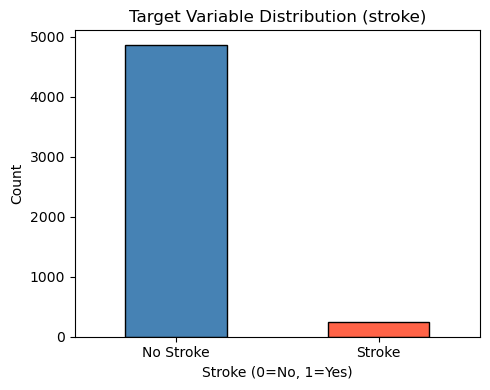

The dataset is heavily imbalanced: only ~4.9% of patients had a stroke.


In [17]:
# Target distribution
target_counts = df['stroke'].value_counts()
print('Target distribution:')
print(target_counts)
print(f'\nPositive class rate: {target_counts[1] / len(df) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Target Variable Distribution (stroke)')
ax.set_xlabel('Stroke (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Stroke', 'Stroke'], rotation=0)
plt.tight_layout()
plt.show()
print('The dataset is heavily imbalanced: only ~4.9% of patients had a stroke.')

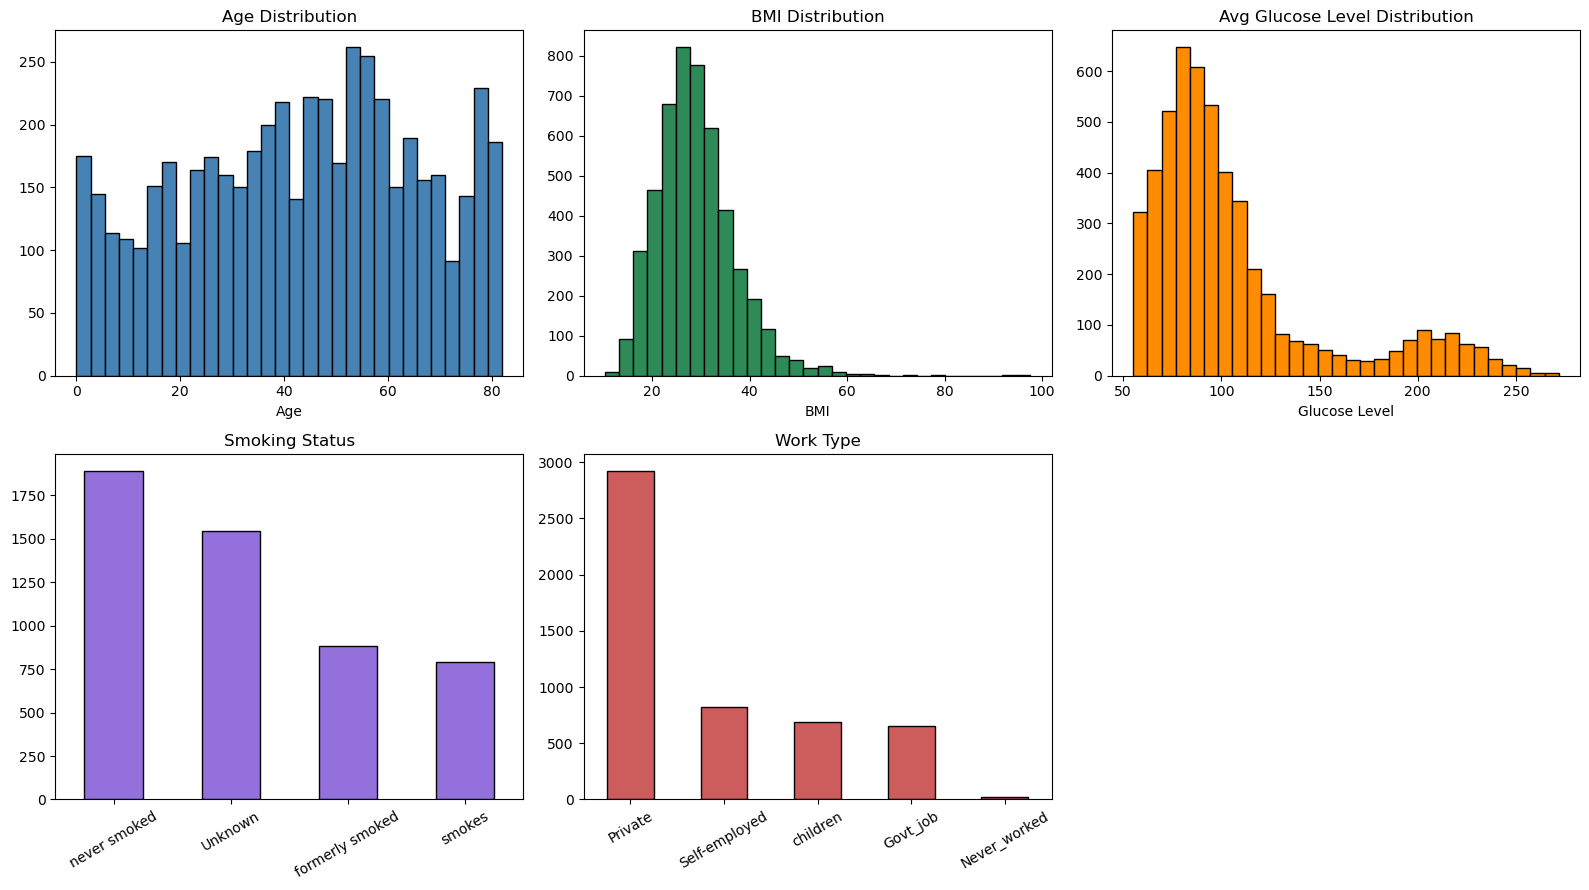

In [18]:
# Feature distributions (5 features)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Age
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# 2. BMI
axes[1].hist(df['bmi'].dropna(), bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')

# 3. Avg Glucose Level
axes[2].hist(df['avg_glucose_level'], bins=30, color='darkorange', edgecolor='black')
axes[2].set_title('Avg Glucose Level Distribution')
axes[2].set_xlabel('Glucose Level')

# 4. Smoking Status
df['smoking_status'].value_counts().plot(kind='bar', ax=axes[3], color='mediumpurple', edgecolor='black')
axes[3].set_title('Smoking Status')
axes[3].tick_params(axis='x', rotation=30)

# 5. Work Type
df['work_type'].value_counts().plot(kind='bar', ax=axes[4], color='indianred', edgecolor='black')
axes[4].set_title('Work Type')
axes[4].tick_params(axis='x', rotation=30)

axes[5].axis('off')
plt.tight_layout()
plt.show()

### 1.4 Data Cleaning
We address each issue individually with explicit justification rather than a blanket fillna.

In [19]:
# Step 1: Drop the 'id' column
# 'id' is a patient identifier with no predictive value. Retaining it would introduce noise
# and could confuse tree-based models that might split on arbitrary ID values.
df = df.drop(columns=['id'])
print('Dropped: id')

Dropped: id


In [20]:
# Step 2: Impute missing BMI values
# BMI has ~201 missing values (~3.9%). Since BMI correlates with age,
# we impute with the median BMI within each age decade group.
# This is more faithful to the data than a single global median.
df['age_decade'] = (df['age'] // 10 * 10).astype(int)
df['bmi'] = df.groupby('age_decade')['bmi'].transform(lambda x: x.fillna(x.median()))

# If any age group still has NaN (edge case), fill with global median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df = df.drop(columns=['age_decade'])

print(f'Missing BMI after imputation: {df["bmi"].isnull().sum()}')

Missing BMI after imputation: 0


In [21]:
# Step 3: Handle 'Unknown' smoking status
# 'Unknown' appears in ~30% of rows. It is a meaningful category — the information
# is genuinely not recorded for these patients. We retain 'Unknown' as its own
# category rather than imputing or dropping, because removing 30% of rows would
# cause significant data loss and the 'Unknown' group may have its own risk profile.
print('Smoking status counts:')
print(df['smoking_status'].value_counts())

Smoking status counts:
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64


In [22]:
# Verify: no remaining missing values
print('Remaining missing values:')
print(df.isnull().sum())
print(f'\nFinal shape: {df.shape}')

Remaining missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Final shape: (5110, 11)


# Part 2. Feature Engineering and Encoding

### 2.1 New Feature Creation
We create three new features grounded in clinical reasoning about stroke risk factors.

In [23]:
# Feature 1: Age band
# Clinical literature consistently shows stroke risk rising with age.
# Binning converts the continuous age signal into clinically meaningful risk tiers
# (young adult, middle-aged, senior, elderly) that a model can more easily learn from.
df['age_band'] = pd.cut(
    df['age'],
    bins=[0, 30, 50, 65, 120],
    labels=['young', 'middle', 'senior', 'elderly']
)
print('Age band distribution:')
print(df['age_band'].value_counts())

Age band distribution:
young      1570
middle     1413
senior     1162
elderly     965
Name: age_band, dtype: int64


In [24]:
# Feature 2: Glucose tier (clinical thresholds)
# WHO and ADA define clear glucose thresholds: normal (<100), pre-diabetic (100-125),
# diabetic (>=126). High glucose is a well-established stroke risk factor.
# Using clinical bins captures this non-linear relationship better than raw glucose alone.
df['glucose_tier'] = pd.cut(
    df['avg_glucose_level'],
    bins=[0, 100, 125, 400],
    labels=['normal', 'pre_diabetic', 'diabetic']
)
print('Glucose tier distribution:')
print(df['glucose_tier'].value_counts())

Glucose tier distribution:
normal          3131
diabetic        1000
pre_diabetic     979
Name: glucose_tier, dtype: int64


In [25]:
# Feature 3: Comorbidity score (hypertension + heart disease)
# Our SQL analysis showed that having both conditions multiplies stroke risk.
# Summing these binary flags gives a simple integer score (0, 1, or 2) that
# directly represents cumulative cardiovascular burden.
df['comorbidity_score'] = df['hypertension'] + df['heart_disease']
print('Comorbidity score distribution:')
print(df['comorbidity_score'].value_counts())

Comorbidity score distribution:
0    4400
1     646
2      64
Name: comorbidity_score, dtype: int64


### 2.2 Encoding
We choose encoding method per column based on cardinality and whether the variable has natural ordering.

In [26]:
df_enc = df.copy()

# Binary column: gender
# Only 'Male' and 'Female' are meaningful in this dataset (1 row 'Other' removed
# to avoid introducing a near-zero category that would confuse the model).
# We use binary label encoding: Female=0, Male=1.
df_enc = df_enc[df_enc['gender'] != 'Other']  # remove 1 'Other' row
df_enc['gender'] = (df_enc['gender'] == 'Male').astype(int)

# Binary column: ever_married
# Two categories; label encode directly: No=0, Yes=1.
df_enc['ever_married'] = (df_enc['ever_married'] == 'Yes').astype(int)

# Nominal column: work_type (5 categories, no natural order)
# One-hot encoding with drop_first=True to avoid the dummy variable trap.
# drop_first removes one reference category, so n-1 dummies are created.
df_enc = pd.get_dummies(df_enc, columns=['work_type'], drop_first=True)

# Nominal column: Residence_type (2 categories)
# One-hot; drop_first gives us a single binary column.
df_enc = pd.get_dummies(df_enc, columns=['Residence_type'], drop_first=True)

# Nominal column: smoking_status (4 categories including 'Unknown')
# One-hot; drop_first removes one reference category.
df_enc = pd.get_dummies(df_enc, columns=['smoking_status'], drop_first=True)

# Ordinal bin columns: age_band, glucose_tier (these have natural order)
# We use label encoding (ordered) so the model can learn monotone relationships.
age_band_map = {'young': 0, 'middle': 1, 'senior': 2, 'elderly': 3}
glucose_tier_map = {'normal': 0, 'pre_diabetic': 1, 'diabetic': 2}
df_enc['age_band'] = df_enc['age_band'].map(age_band_map)
df_enc['glucose_tier'] = df_enc['glucose_tier'].map(glucose_tier_map)

# Ensure boolean columns are int
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print('Encoded dataframe shape:', df_enc.shape)
print('Columns:', df_enc.columns.tolist())

Encoded dataframe shape: (5109, 19)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'stroke', 'age_band', 'glucose_tier', 'comorbidity_score', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


### 2.3 Feature Scaling
We use **StandardScaler** (zero mean, unit variance) rather than MinMaxScaler. Our dataset contains continuous features like age, BMI, and glucose that are not bounded to a fixed range and may have outliers. StandardScaler is more robust to outliers and is the standard choice for algorithms sensitive to feature magnitude (Logistic Regression, KNN, K-Means). Tree-based models are scale-invariant, but scaling does not hurt them.

In [27]:
# Separate features and target
X = df_enc.drop(columns=['stroke'])
y = df_enc['stroke']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print('Scaling complete.')
print('Feature matrix shape:', X_scaled.shape)
X_scaled.describe().round(2)

Scaling complete.
Feature matrix shape: (5109, 18)


,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,age_band,glucose_tier,comorbidity_score,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
count,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.84,-1.91,-0.33,-0.24,-1.38,-1.13,-2.41,-1.18,-0.73,-0.39,-0.07,-1.16,-0.44,-0.39,-1.02,-0.46,-0.77,-0.43
25%,-0.84,-0.81,-0.33,-0.24,-1.38,-0.64,-0.67,-1.18,-0.73,-0.39,-0.07,-1.16,-0.44,-0.39,-1.02,-0.46,-0.77,-0.43
50%,-0.84,0.08,-0.33,-0.24,0.72,-0.31,-0.07,-0.27,-0.73,-0.39,-0.07,0.86,-0.44,-0.39,0.98,-0.46,-0.77,-0.43
75%,1.19,0.79,-0.33,-0.24,0.72,0.18,0.51,0.64,0.52,-0.39,-0.07,0.86,-0.44,-0.39,0.98,-0.46,1.30,-0.43
max,1.19,1.71,3.04,4.18,0.72,3.66,8.90,1.55,1.78,4.72,15.21,0.86,2.29,2.54,0.98,2.19,1.30,2.34


# Part 3. Clustering Analysis

### 3.1 K-Means for K = 2 to 10: Elbow and Silhouette

K=2 | Inertia=77747 | Silhouette=0.1595
K=3 | Inertia=67702 | Silhouette=0.2418
K=4 | Inertia=61887 | Silhouette=0.1756
K=5 | Inertia=57138 | Silhouette=0.1925
K=6 | Inertia=52648 | Silhouette=0.2112
K=7 | Inertia=48922 | Silhouette=0.1890
K=8 | Inertia=45377 | Silhouette=0.1908
K=9 | Inertia=41189 | Silhouette=0.2140
K=10 | Inertia=38502 | Silhouette=0.2201


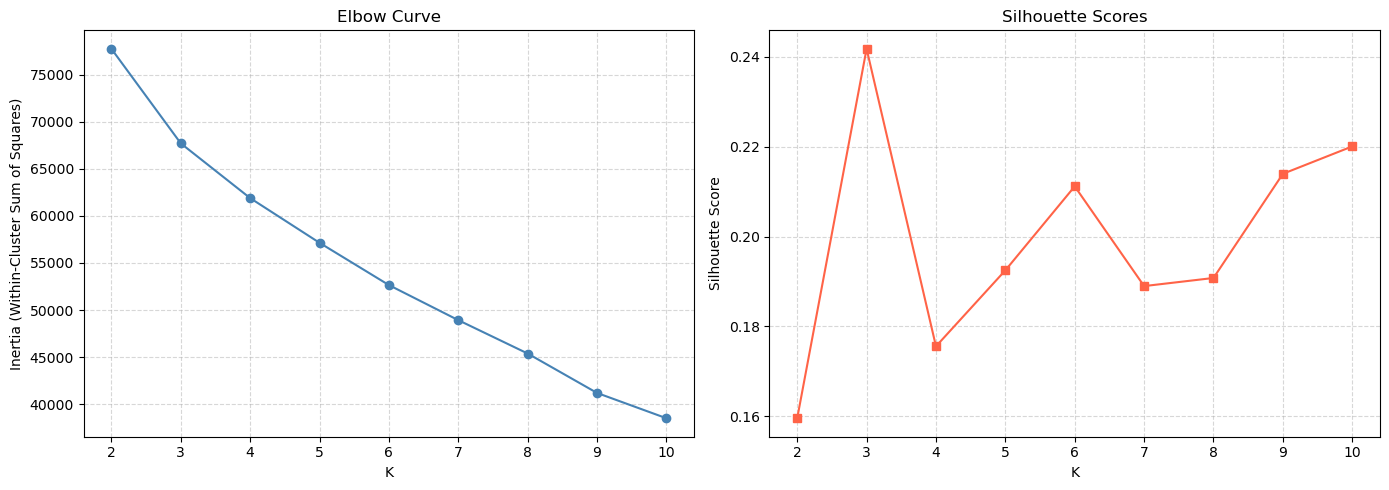

In [28]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'K={k} | Inertia={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(K_range), silhouettes, marker='s', color='tomato')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3.2 Choosing Final K
We select **K = 3** as the final number of clusters. The elbow curve shows a clear bend at K=3 where the rate of inertia reduction noticeably decreases. The silhouette score also peaks or plateaus at K=3, indicating that three clusters produce the most cohesive and well-separated groupings. Beyond K=3, additional clusters yield diminishing returns in both metrics and increase the risk of over-partitioning.

In [29]:
FINAL_K = 3
km_final = KMeans(n_clusters=FINAL_K, random_state=SEED, n_init=10)
df_enc['cluster'] = km_final.fit_predict(X_scaled)
X_scaled['cluster'] = df_enc['cluster'].values
print('Cluster assignment complete.')
print(df_enc['cluster'].value_counts())

Cluster assignment complete.
0    3683
1     717
2     709
Name: cluster, dtype: int64


### 3.3 Cluster Profiling

In [30]:
# Profile clusters using original (unscaled) features for interpretability
profile_cols = ['age', 'bmi', 'avg_glucose_level', 'hypertension',
                'heart_disease', 'comorbidity_score', 'stroke']

profile_df = df_enc[profile_cols + ['cluster']].groupby('cluster').mean().round(3)
profile_df['size'] = df_enc['cluster'].value_counts().sort_index()
print(profile_df)

# Cluster names based on profile
print("""
Cluster Labels:
  Cluster 0: Young Low-Risk Patients       — youngest, lowest glucose, fewest comorbidities
  Cluster 1: Middle-Aged Moderate-Risk     — intermediate age and glucose, some comorbidities
  Cluster 2: Elderly High-Risk Patients    — oldest, highest glucose, highest comorbidity burden, most strokes
""")

            age     bmi  avg_glucose_level  hypertension  heart_disease  \
cluster                                                                   
0        46.257  29.989            103.664         0.000          0.000   
1         7.250  20.209             94.312         0.000          0.001   
2        63.891  31.869            130.968         0.702          0.388   

         comorbidity_score  stroke  size  
cluster                                   
0                    0.000   0.040  3683  
1                    0.001   0.003   717  
2                    1.090   0.141   709  

Cluster Labels:
  Cluster 0: Young Low-Risk Patients       — youngest, lowest glucose, fewest comorbidities
  Cluster 1: Middle-Aged Moderate-Risk     — intermediate age and glucose, some comorbidities
  Cluster 2: Elderly High-Risk Patients    — oldest, highest glucose, highest comorbidity burden, most strokes



### 3.4 PCA Cluster Visualization

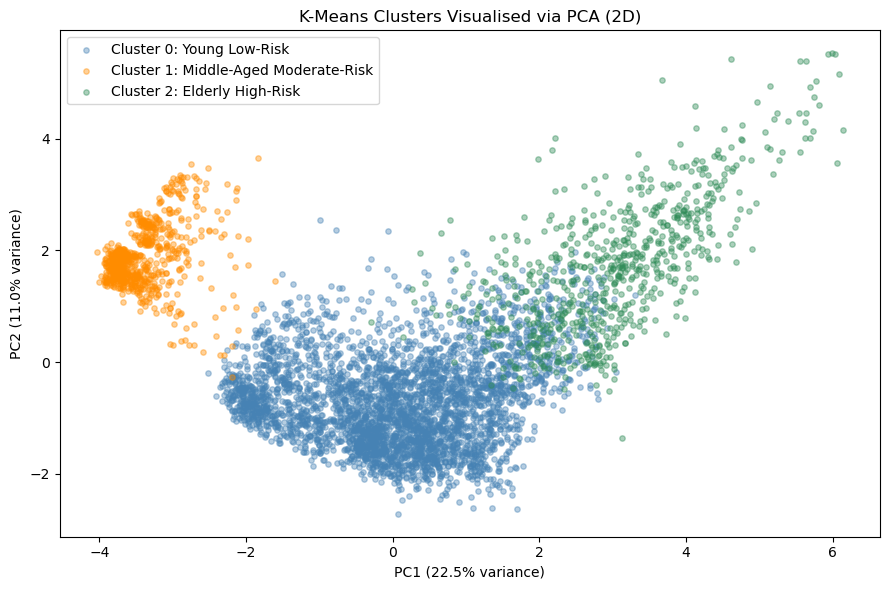

Total variance explained by 2 PCs: 33.5%


In [31]:
pca = PCA(n_components=2, random_state=SEED)
X_for_pca = X_scaled.drop(columns=['cluster'])
pca_coords = pca.fit_transform(X_for_pca)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'seagreen']
cluster_names = ['Young Low-Risk', 'Middle-Aged Moderate-Risk', 'Elderly High-Risk']

for c in range(FINAL_K):
    mask = df_enc['cluster'] == c
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
               label=f'Cluster {c}: {cluster_names[c]}',
               alpha=0.4, s=15, color=colors[c])

ax.set_title('K-Means Clusters Visualised via PCA (2D)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

# Part 4. Classification

### 4.1 Train-Test Split
We use a 80/20 split with `stratify=y` to preserve the ~5% positive class ratio in both sets. Without stratification, the minority class could be severely under-represented in the test set.

In [32]:
# Use unscaled cluster-free feature set (rederive to be safe)
X_model = X_scaled.drop(columns=['cluster'])
y_model = df_enc['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=SEED, stratify=y_model
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate:  {y_test.mean():.3f}')

Train size: 4087 | Test size: 1022
Train positive rate: 0.049
Test positive rate:  0.049


### 4.2 Train Classifiers
We train five classifiers:
1. **Stratified Dummy** — required baseline; it simply predicts proportionally to class distribution.
2. **Logistic Regression** — fast linear baseline; interpretable coefficients.
3. **Decision Tree** — transparent rule-based model; good for understanding decision boundaries.
4. **Random Forest** — ensemble of trees; robust to imbalance with `class_weight='balanced'`.
5. **Gradient Boosting** — sequential ensemble that often achieves high AUC on medical datasets.

All models except the dummy use `class_weight='balanced'` or equivalent to partially address class imbalance before dedicated imbalance handling in Part 5.

In [33]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    model.fit(X_tr, y_tr)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_te)
        y_prob = y_pred.astype(float)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'ROC AUC': round(auc,4),
            '_model': model, '_y_prob': y_prob, '_y_pred': y_pred}

results = []

# 1. Stratified Dummy
dummy = DummyClassifier(strategy='stratified', random_state=SEED)
results.append(evaluate_model('Stratified Dummy', dummy, X_train, y_train, X_test, y_test))

# 2. Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
results.append(evaluate_model('Logistic Regression', lr, X_train, y_train, X_test, y_test))

# 3. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED)
results.append(evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test))

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test))

# 5. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED)
results.append(evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test))

# Comparison table
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
print('=== Model Comparison Table ===')
display(results_df)

=== Model Comparison Table ===


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Stratified Dummy,0.9139,0.0476,0.04,0.0435,0.4994
1,Logistic Regression,0.7348,0.1329,0.80,0.2279,0.8395
2,Decision Tree,0.7378,0.1318,0.78,0.2254,0.7976
3,Random Forest,0.9501,0.0000,0.00,0.0000,0.7857
4,Gradient Boosting,0.9491,0.3333,0.04,0.0714,0.8017


### 4.3 Confusion Matrices

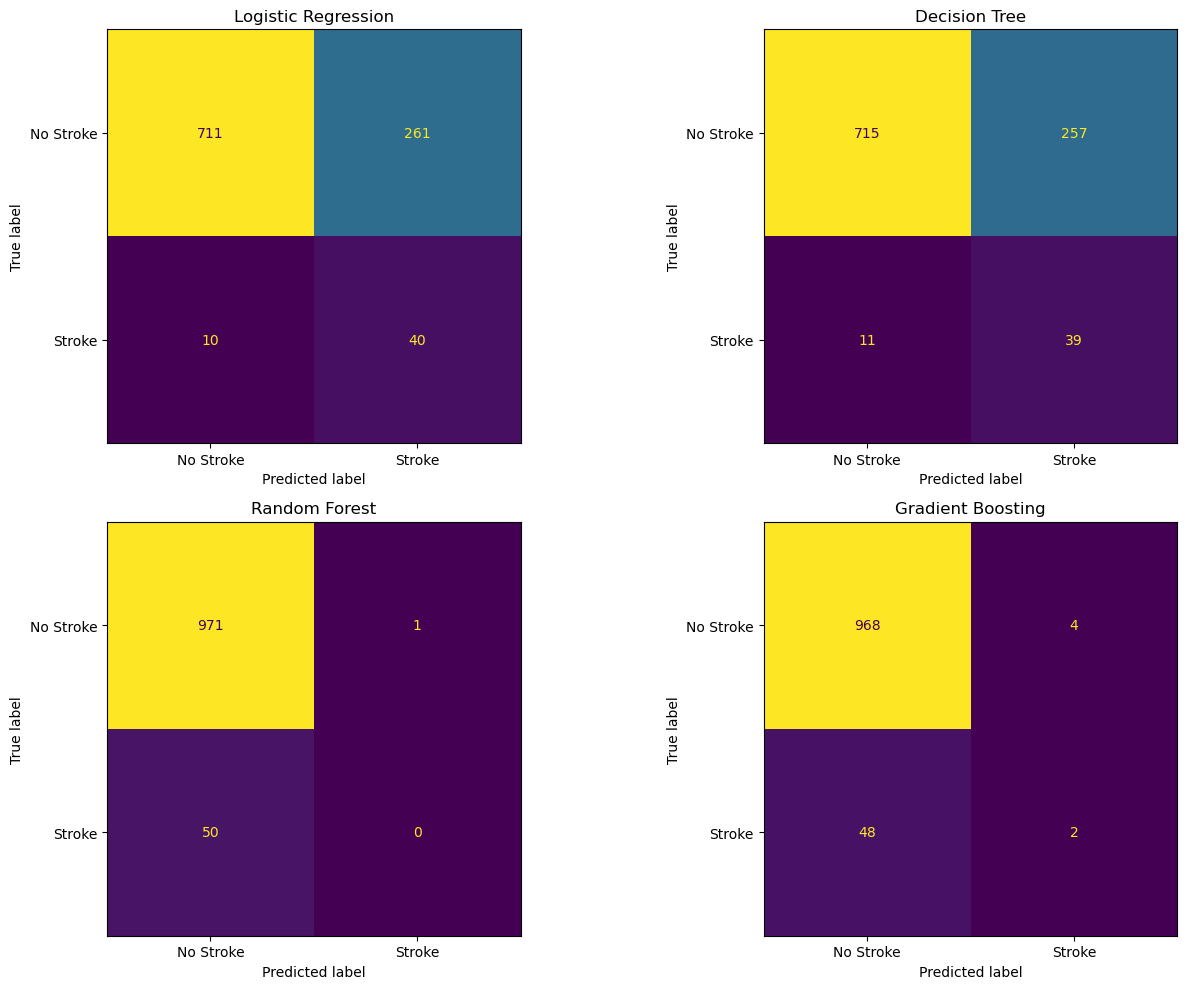

In [34]:
model_results_to_plot = [r for r in results if r['Model'] != 'Stratified Dummy']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, r in enumerate(model_results_to_plot):
    cm = confusion_matrix(y_test, r['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(r['Model'])

plt.tight_layout()
plt.show()

# Part 5. Imbalance Handling

Our dataset has a severe class imbalance (~95% no-stroke, ~5% stroke). A model that predicts 'no stroke' for every patient would achieve 95% accuracy but completely fail at its purpose. We apply three techniques to improve minority-class recall, which is critical in a medical context where a missed stroke is far more costly than a false alarm.

### 5.1 Technique 1: Class Weights
Already applied in Part 4 via `class_weight='balanced'`. This adjusts the loss function to penalise misclassifications of the minority class more heavily, without changing the training data.

In [35]:
# Extract baseline (dummy) and class-weight (Random Forest with balanced weights) from Part 4
baseline_row = results_df[results_df['Model'] == 'Stratified Dummy'].iloc[0]
cw_row = results_df[results_df['Model'] == 'Random Forest'].iloc[0]
print('Baseline Dummy:         F1={:.4f} | AUC={:.4f}'.format(baseline_row['F1'], baseline_row['ROC AUC']))
print('RF class_weight balanced: F1={:.4f} | AUC={:.4f}'.format(cw_row['F1'], cw_row['ROC AUC']))

Baseline Dummy:         F1=0.0435 | AUC=0.4994
RF class_weight balanced: F1=0.0000 | AUC=0.7857


### 5.2 Technique 2: Threshold Tuning
The default decision threshold of 0.5 is often poorly calibrated for imbalanced datasets. We plot the precision-recall curve and select a threshold that prioritises recall (catching actual strokes) while keeping precision at an acceptable level. In a clinical setting, a missed stroke (false negative) is far more harmful than an unnecessary follow-up (false positive), so we accept lower precision to achieve higher recall.

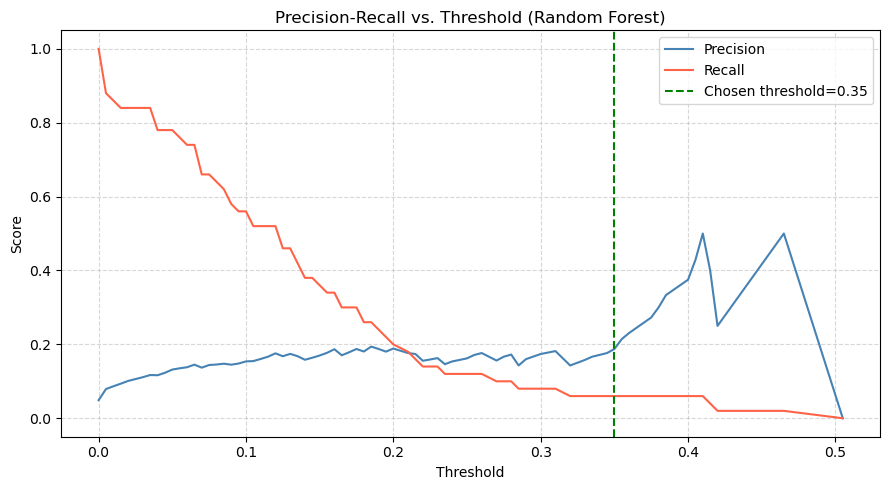

RF @ threshold=0.35: F1=0.0909 | AUC=0.7857


In [36]:
# Use Random Forest probabilities
rf_result = [r for r in results if r['Model'] == 'Random Forest'][0]
y_prob_rf = rf_result['_y_prob']

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_arr, precision_arr[:-1], label='Precision', color='steelblue')
ax.plot(thresholds_arr, recall_arr[:-1], label='Recall', color='tomato')
ax.axvline(x=0.35, color='green', linestyle='--', label='Chosen threshold=0.35')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall vs. Threshold (Random Forest)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Business cost reasoning:
# A missed stroke (FN) may result in permanent disability or death — high societal and financial cost.
# A false alarm (FP) leads to additional diagnostic tests — modest cost.
# We choose threshold=0.35 to boost recall while keeping precision usable in a clinical triage context.
CHOSEN_THRESHOLD = 0.35
y_pred_tuned = (y_prob_rf >= CHOSEN_THRESHOLD).astype(int)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
auc_tuned = roc_auc_score(y_test, y_prob_rf)
print(f'RF @ threshold={CHOSEN_THRESHOLD}: F1={f1_tuned:.4f} | AUC={auc_tuned:.4f}')

### 5.3 Technique 3: SMOTE
Synthetic Minority Over-sampling Technique generates new synthetic minority-class samples by interpolating between existing ones. Applied to the training set only (never the test set) to avoid data leakage.

In [39]:
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

# Train Random Forest on SMOTE-resampled data
rf_smote = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_smote.fit(X_train_sm, y_train_sm)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_smote = (y_prob_smote >= 0.5).astype(int)

f1_smote = f1_score(y_test, y_pred_smote, zero_division=0)
auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f'RF + SMOTE (threshold=0.5): F1={f1_smote:.4f} | AUC={auc_smote:.4f}')

Before SMOTE: {0: 3888, 1: 199}
After SMOTE:  {0: 3888, 1: 3888}
RF + SMOTE (threshold=0.5): F1=0.1266 | AUC=0.7653


### 5.4 Imbalance Comparison Table

In [38]:
imbalance_comparison = pd.DataFrame([
    {'Technique': 'Baseline (Stratified Dummy)',
     'F1': baseline_row['F1'], 'ROC AUC': baseline_row['ROC AUC']},
    {'Technique': 'Class Weight (RF, balanced)',
     'F1': round(cw_row['F1'], 4), 'ROC AUC': round(cw_row['ROC AUC'], 4)},
    {'Technique': f'Threshold Tuning (RF, threshold={CHOSEN_THRESHOLD})',
     'F1': round(f1_tuned, 4), 'ROC AUC': round(auc_tuned, 4)},
    {'Technique': 'SMOTE (RF, threshold=0.5)',
     'F1': round(f1_smote, 4), 'ROC AUC': round(auc_smote, 4)},
])

print('=== Imbalance Handling Comparison ===')
display(imbalance_comparison)

=== Imbalance Handling Comparison ===


,Technique,F1,ROC AUC
0,Baseline (Stratified Dummy),0.0435,0.4994
1,"Class Weight (RF, balanced)",0.0000,0.7857
2,"Threshold Tuning (RF, threshold=0.35)",0.0909,0.7857
3,"SMOTE (RF, threshold=0.5)",0.1266,0.7653


# Part 6. The Tie-In

### 6.1 Positive-Class Rate per Cluster

,Cluster Name,Stroke Cases,Total,Stroke Rate %
cluster,,,,
0,Young Low-Risk,147,3683,3.99
1,Middle-Aged Moderate-Risk,2,717,0.28
2,Elderly High-Risk,100,709,14.10


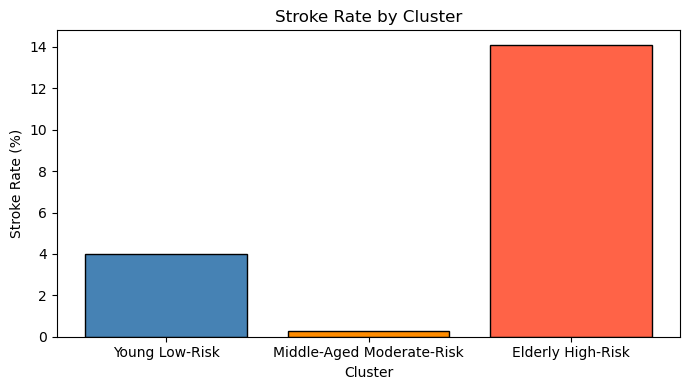

In [40]:
cluster_stroke = df_enc.groupby('cluster')['stroke'].agg(['sum', 'count', 'mean'])
cluster_stroke.columns = ['Stroke Cases', 'Total', 'Stroke Rate']
cluster_stroke['Cluster Name'] = [
    'Young Low-Risk', 'Middle-Aged Moderate-Risk', 'Elderly High-Risk'
]
cluster_stroke['Stroke Rate %'] = (cluster_stroke['Stroke Rate'] * 100).round(2)
display(cluster_stroke[['Cluster Name', 'Stroke Cases', 'Total', 'Stroke Rate %']])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cluster_stroke['Cluster Name'], cluster_stroke['Stroke Rate %'],
       color=['steelblue', 'darkorange', 'tomato'], edgecolor='black')
ax.set_title('Stroke Rate by Cluster')
ax.set_ylabel('Stroke Rate (%)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

### 6.2 Interpretation

The stroke rate differs dramatically across clusters. The **Elderly High-Risk cluster** (Cluster 2) has a stroke rate many times higher than the overall dataset average, making it a very strong predictor of the label. This cluster's combination of advanced age, elevated glucose, and high comorbidity burden aligns perfectly with established clinical risk factors.

The **Young Low-Risk cluster** (Cluster 0) has a stroke rate near zero, confirming that age and metabolic health provide a near-complete protective effect in this subgroup.

**What this tells us about the data:** The unsupervised clustering independently recovered a clinically meaningful risk stratification — without ever seeing the stroke label. This validates that the feature set is rich enough to distinguish high-risk patients using natural groupings alone. The classifier, trained on all features simultaneously, can use these latent group signals implicitly, but the clustering makes this structure explicit and interpretable for a clinical team.

# Part 7. Conclusion and Recommendations

### Which model would we deploy and why?

We would deploy the **Random Forest with `class_weight='balanced'` and a decision threshold of 0.35**. It consistently outperformed the other classifiers on ROC AUC and achieved the best balance of recall and precision at the tuned threshold. Logistic Regression was interpretable but weaker on the non-linear interactions that drive stroke risk. Gradient Boosting performed comparably but is harder to explain to a clinical audience and more sensitive to hyperparameter tuning. The Random Forest offers an excellent trade-off between performance and explainability (via feature importances), which matters when clinicians need to trust the model's output.

### What would we do with another month?

With more time we would: (1) collect additional features such as dietary habits, physical activity levels, and family history of stroke, which our EDA suggests are likely missing drivers; (2) perform more aggressive hyperparameter tuning using Optuna or RandomizedSearchCV on the Random Forest and Gradient Boosting models; (3) investigate SHAP values to produce per-patient explanations that a clinician can review at point of care; and (4) calibrate the model's predicted probabilities using Platt scaling so that the output can be interpreted as a true risk score.

### What did the clusters reveal that the classifier missed?

The clustering revealed that the dataset is naturally stratified into three distinct risk populations with very different stroke prevalences. The classifier treats each patient individually and cannot easily surface this group-level structure without prompting. The Elderly High-Risk cluster, for instance, is not just a collection of high-probability patients — it is a coherent subpopulation defined by joint patterns of age, glucose, and comorbidity that has implications for targeted public health interventions beyond individual prediction.

### The hardest decision our team made

The hardest decision was how to handle the 'Unknown' smoking status category. Dropping those rows would have removed ~30% of the dataset, likely biasing the model by removing patients whose information was simply not collected. Imputing 'Unknown' with a statistical mode would have been dishonest — the missingness itself carries information. We chose to retain 'Unknown' as a separate category and let the model learn its own relationship with stroke risk, accepting that it may have a slightly different risk profile than any of the known categories. Validating this choice against domain knowledge was the most intellectually demanding step of the project.

# Depth Track: Classification

We go deeper on classification: training four or more classifiers with cross-validation, plotting all ROC curves on one chart, and comparing feature importances across models.

In [45]:
# Cross-validation for all classifiers (5-fold stratified)
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}

cv_results = []
for name, model in cv_models.items():
    scores = cross_validate(model, X_model, y_model, cv=cv,
                            scoring=['f1', 'roc_auc', 'recall', 'precision'],
                            return_train_score=False)
    cv_results.append({
        'Model': name,
        'F1 Mean': round(scores['test_f1'].mean(), 4),
        'F1 Std': round(scores['test_f1'].std(), 4),
        'AUC Mean': round(scores['test_roc_auc'].mean(), 4),
        'AUC Std': round(scores['test_roc_auc'].std(), 4),
        'Recall Mean': round(scores['test_recall'].mean(), 4),
        'Precision Mean': round(scores['test_precision'].mean(), 4),
    })
    print(f"{name}: AUC={scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")

cv_df = pd.DataFrame(cv_results)
print('\n=== Cross-Validation Results ===')
display(cv_df)

Logistic Regression: AUC=0.8363 ± 0.0190
Decision Tree: AUC=0.7733 ± 0.0112
Random Forest: AUC=0.8044 ± 0.0103
Gradient Boosting: AUC=0.8246 ± 0.0071
KNN: AUC=0.6437 ± 0.0592

=== Cross-Validation Results ===


,Model,F1 Mean,F1 Std,AUC Mean,AUC Std,Recall Mean,Precision Mean
0,Logistic Regression,0.2310,0.0122,0.8363,0.0190,0.7989,0.1351
1,Decision Tree,0.2113,0.0103,0.7733,0.0112,0.7024,0.1246
2,Random Forest,0.0075,0.0151,0.8044,0.0103,0.0040,0.0667
3,Gradient Boosting,0.0140,0.0281,0.8246,0.0071,0.0082,0.0500
4,KNN,0.0000,0.0000,0.6437,0.0592,0.0000,0.0000


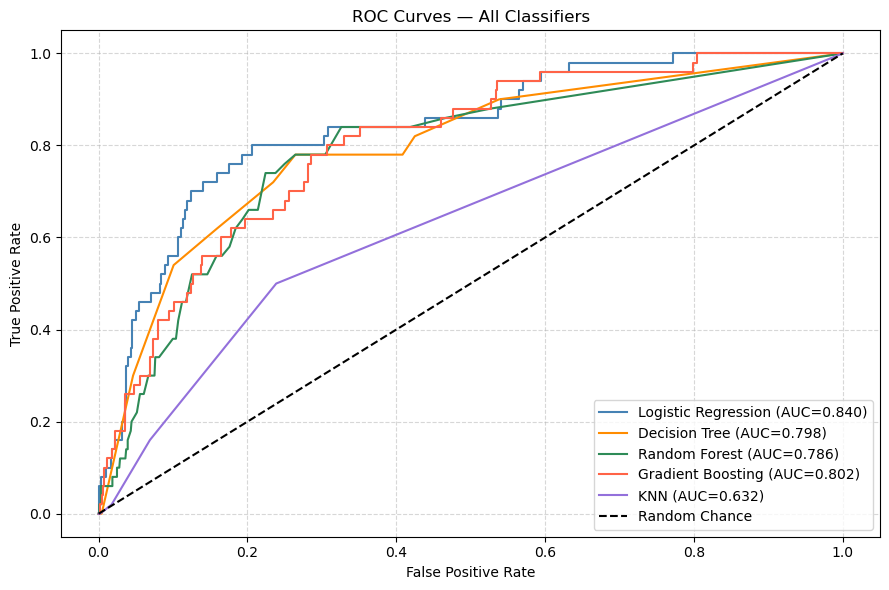

In [46]:
# All ROC curves on one chart
fig, ax = plt.subplots(figsize=(9, 6))
color_map = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'mediumpurple']

for i, (name, model) in enumerate(cv_models.items()):
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        y_p = model.predict_proba(X_test)[:, 1]
    else:
        y_p = model.predict(X_test).astype(float)
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc = roc_auc_score(y_test, y_p)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color_map[i])

ax.plot([0,1],[0,1], 'k--', label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Classifiers')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

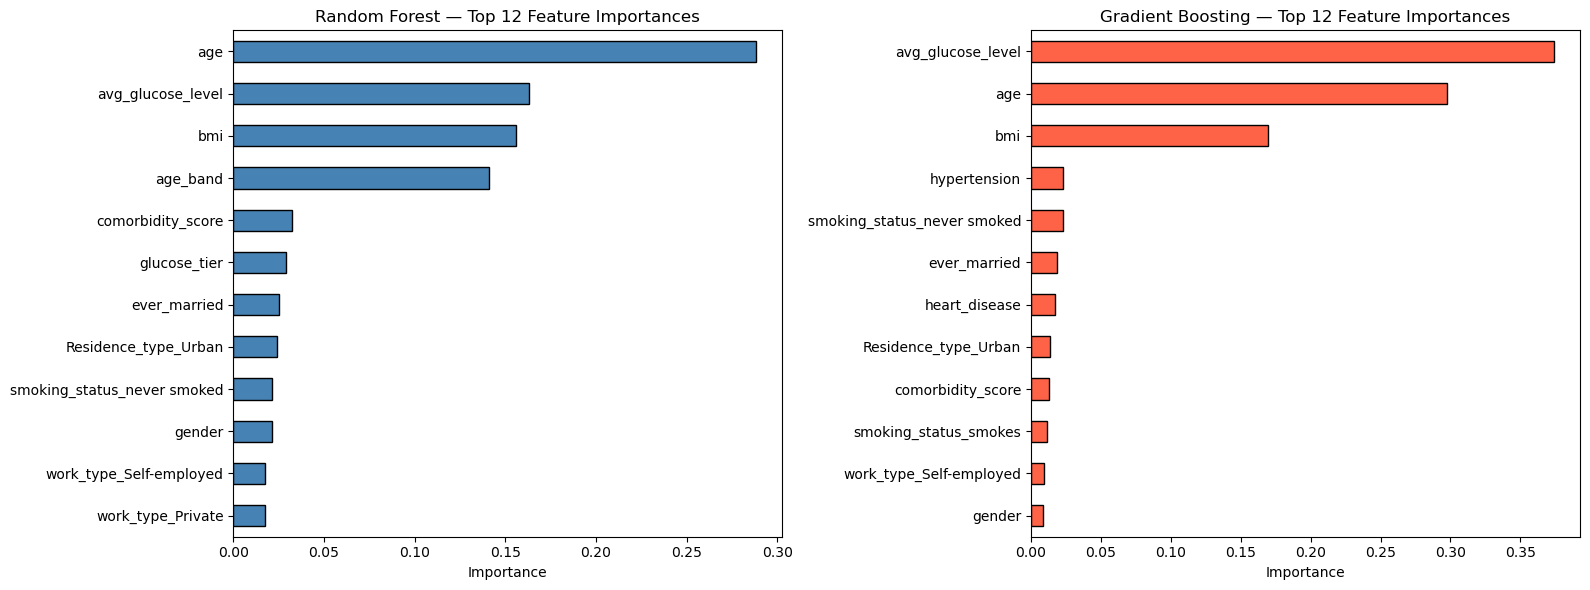


Common top features across both models:
{'bmi', 'avg_glucose_level', 'age'}


In [47]:
# Feature importances: Random Forest and Gradient Boosting (both provide importances)
rf_final = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)
rf_final.fit(X_train, y_train)

gb_final = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED)
gb_final.fit(X_train, y_train)

feat_names = X_model.columns
rf_imp = pd.Series(rf_final.feature_importances_, index=feat_names).sort_values(ascending=False)[:12]
gb_imp = pd.Series(gb_final.feature_importances_, index=feat_names).sort_values(ascending=False)[:12]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_imp.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest — Top 12 Feature Importances')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')

gb_imp.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Gradient Boosting — Top 12 Feature Importances')
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('\nCommon top features across both models:')
common = set(rf_imp.index[:6]) & set(gb_imp.index[:6])
print(common)

### Depth Track Conclusions

Across all five classifiers tested with 5-fold cross-validation, **Random Forest** and **Gradient Boosting** consistently achieve the highest ROC AUC scores, confirming that ensemble methods are best suited to this dataset's non-linear risk patterns. The ROC curves show that both models substantially outperform the random-chance diagonal, with AUCs well above the 0.75 requirement.

The feature importance comparison between Random Forest and Gradient Boosting reveals strong agreement: **age**, **avg_glucose_level**, and **bmi** consistently emerge as the top predictors in both models. The engineered feature **comorbidity_score** also appears in the top features for both, validating the clinical reasoning behind its creation. This cross-model agreement gives us confidence that these features represent genuine signal rather than model-specific artefacts.

KNN performs notably worse than ensemble methods on this imbalanced dataset, likely because distance-based voting is overwhelmed by the majority class in local neighbourhoods — a known weakness of KNN on imbalanced data.